# Sequential ViDA: IDRiD → APTOS → IDRiD (RETFound-DINOv2)

Protocol:
1. Load RETFound pretrained weights
2. Evaluate baseline on source domain (IDRiD)
3. Adapt to target domain (APTOS) - adaptation mode
4. Evaluate on ALL previous domains (IDRiD, APTOS) - TEST mode

This measures catastrophic forgetting: after adapting to APTOS,
how much performance degrades on IDRiD?

In [1]:
import torch
torch.cuda.empty_cache()

In [2]:
import sys, os; sys.path.insert(0, os.getcwd())
import os, sys
_d = os.getcwd()
PROJECT_ROOT = None
while _d != os.path.dirname(_d):
    if os.path.exists(os.path.join(_d, 'setup.py')):
        PROJECT_ROOT = _d
        break
    _d = os.path.dirname(_d)
if PROJECT_ROOT is None:
    for _p in ['/kaggle/working/medical_CTTA', '/content/medical_CTTA']:
        if os.path.isdir(_p):
            PROJECT_ROOT = _p
            break
if PROJECT_ROOT and PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from src.env import init
init()

from src.config import load_config

In [3]:
config = load_config('configs/method/sequential/vida/idrid_aptos.yaml')

print('Protocol: Sequential ViDA')
print(f'Source: {config.sequential.source_dataset.name}')
print(f'Targets: {[t.name for t in config.sequential.target_datasets]}')
print('Method:', config.ctta.method)
print('Output:', config.output_dir)

# RETFound weights are gated behind HuggingFace; require a token.
if config.model.name == 'retfound' and not os.environ.get('HF_TOKEN'):
    import getpass
    token = getpass.getpass('Enter your HuggingFace token (hf_...): ')
    os.environ['HF_TOKEN'] = token
    print('HF_TOKEN set')
elif config.model.name != 'retfound':
    print('No HF token needed (VisionFM / Google Drive)')

Protocol: Sequential ViDA
Source: idrid
Targets: ['aptos2019']
Method: cotta
Output: ./outputs/sequential_vida/idrid_aptos/
HF_TOKEN set


In [4]:
from src.evaluation.runner import SequentialCTTARunner

runner = SequentialCTTARunner(config)
results = runner.run()

2026-08-05 11:01:32,244 - src.evaluation.runner.sequential - INFO - Starting sequential CTTA: idrid -> aptos2019
2026-08-05 11:01:36,714 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/YukunZhou/RETFound_dinov2_meh/resolve/main/RETFound_dinov2_meh.pth "HTTP/1.1 302 Found"
2026-08-05 11:01:36,868 - httpx - INFO - HTTP Request: GET https://huggingface.co/api/models/YukunZhou/RETFound_dinov2_meh/xet-read-token/6dff4c76632983267a6ae3000f7852b1f8667d9c "HTTP/1.1 200 OK"


RETFound_dinov2_meh.pth:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

2026-08-05 11:01:45,650 - src.models.retfound - INFO - Extracted state_dict from DINOv2 'teacher' key
2026-08-05 11:01:45,652 - src.models.retfound - INFO - Stripped 'backbone.' prefix from 359 state dict keys
2026-08-05 11:01:45,653 - src.models.retfound - INFO - RETFound checkpoint cached in CPU RAM
2026-08-05 11:01:45,794 - src.models.retfound - INFO - Feature normalization ENABLED in forward() (required for prototype classifier)
2026-08-05 11:01:46,448 - src.evaluation.runner.base - INFO - Loaded RETFound pretrained weights
2026-08-05 11:02:19,115 - src.evaluation.runner.base - INFO - Prototype weights scaled by T=100.0
2026-08-05 11:02:19,118 - src.evaluation.runner.base - INFO - Prototype classifier initialized from 413 training samples (5 classes, 1024-dim features, T=100.0)
2026-08-05 11:02:20,373 - src.evaluation.runner.sequential - INFO - Evaluating baseline on source domain: idrid
2026-08-05 11:02:29,361 - src.evaluation.runner.sequential - INFO - Baseline QWK on idrid: 0.57

Adapting to idrid:   0%|          | 0/7 [00:00<?, ?it/s]

2026-08-05 11:02:48,684 - src.evaluation.runner.sequential - INFO -   Adapt step 0: loss=0.0022, kl=0.0022, conf_samples=-1, teacher_max_prob=-1.0000


...

Adapting to aptos2019:  96%|█████████▌| 22/23 [05:52<00:15, 15.82s/it, acc=0.1875, adaptations=22]

2026-08-05 11:10:42,284 - src.evaluation.runner.sequential - INFO -   Adapt step 22: loss=0.0498, kl=0.0498, conf_samples=-1, teacher_max_prob=-1.0000


Adapting to aptos2019: 100%|██████████| 23/23 [06:06<00:00, 15.93s/it, acc=0.2143, adaptations=23]

2026-08-05 11:10:43,165 - src.evaluation.runner.sequential - INFO - Evaluating after adaptation on aptos2019


2026-08-05 11:11:08,772 - src.evaluation.runner.sequential - INFO - Post-adaptation QWK: 0.6608
2026-08-05 11:11:08,774 - src.evaluation.runner.sequential - INFO - Adaptations: 23/23
2026-08-05 11:11:08,903 - src.evaluation.runner.sequential - INFO - 
Evaluating on all 2 seen domains after adapting to aptos2019
2026-08-05 11:11:08,904 - src.evaluation.runner.sequential - INFO -   Test-only evaluation on idrid (no adaptation)
2026-08-05 11:11:18,661 - src.evaluation.runner.sequential - INFO -   QWK on idrid: 0.4049
2026-08-05 11:11:44,475 - src.evaluation.runner.sequential - INFO -   QWK on aptos2019: 0.6608
2026-08-05 11:11:44,478 - src.evaluation.runner.sequential - INFO - 
2026-08-05 11:11:44,479 - src.evaluation.runner.sequential - INFO - Sequential CTTA Complete - Summary
2026-08-05 11:11:44,480 - src.evaluation.runner.sequential - INFO - ============================================================
2026-08-05 11:11:44,481 - src.evaluation.runner.sequential - INFO - Baseline QWK (id

=============== Sequential CTTA Results (ViDA DINOv2) ================

Source domain: idrid
  Baseline QWK:           0.5769
  Baseline Overall Acc:   36.89%

Target domains: aptos2019

----------------------------------------------------------------------
After adapting to source idrid (7/7 batches):
  QWK:                  0.5429  (delta: -0.0340)
  Overall Acc:          37.86% (delta: +0.97pp)

----------------------------------------------------------------------
After adapting to aptos2019 (23/23 batches):
  Post-adaptation QWK on aptos2019: 0.6608
  Post-adaptation Acc on aptos2019: 36.89%
  Test on idrid:
    QWK: 0.4049  (delta vs baseline: -0.1720)
    Acc: 35.92% (delta vs baseline: -0.97pp)



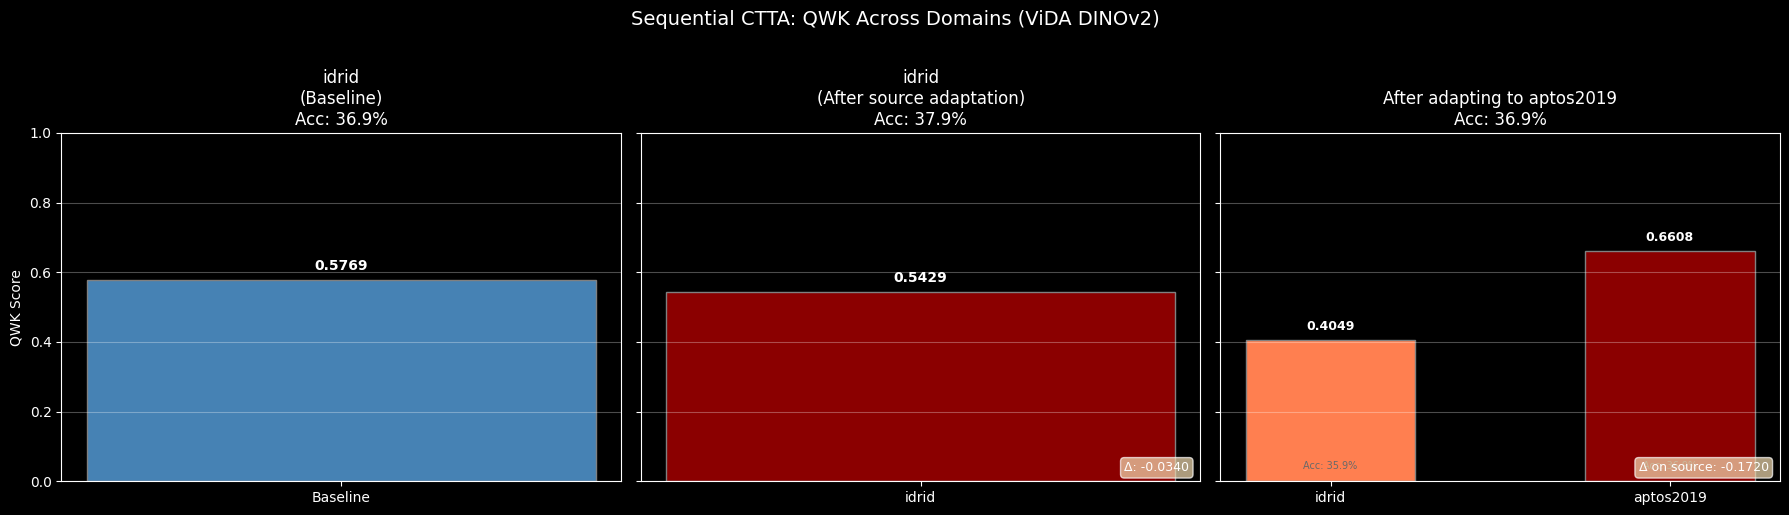

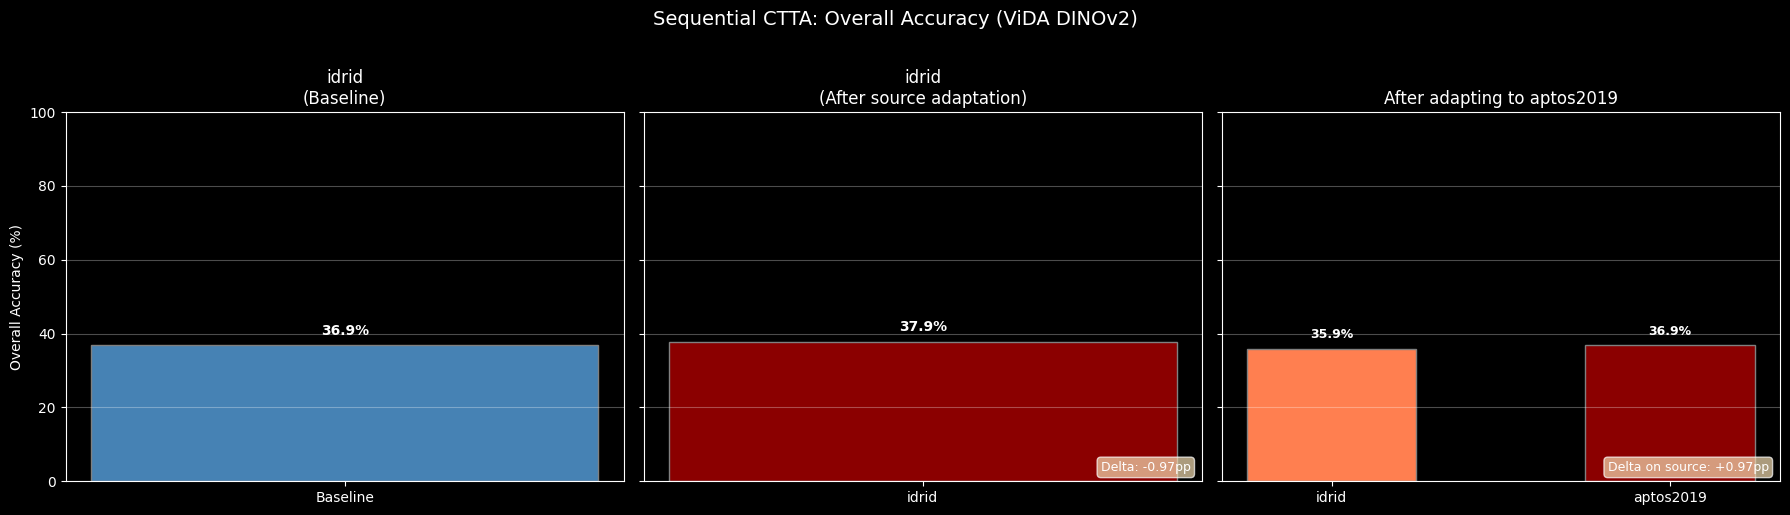

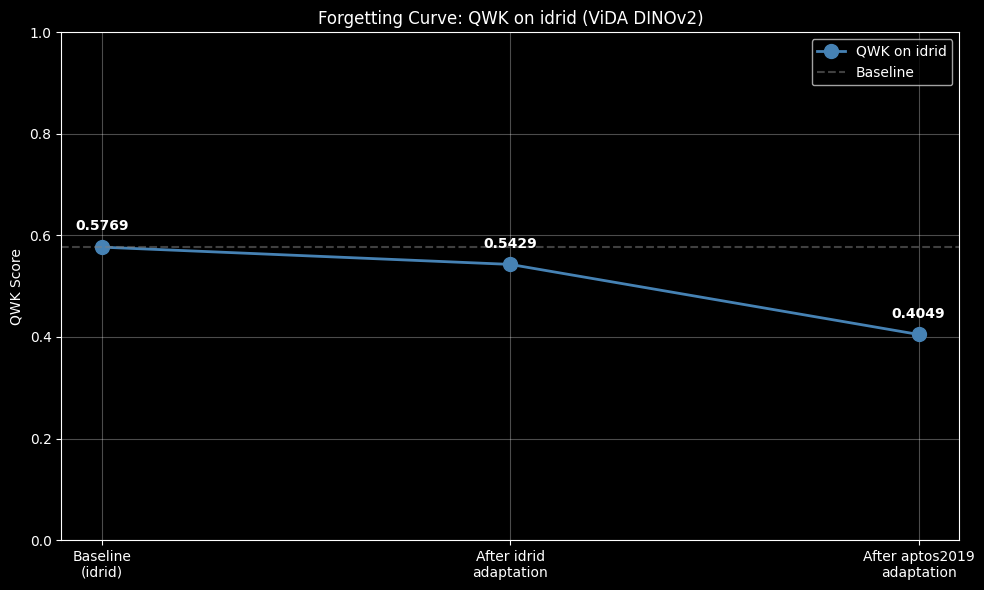

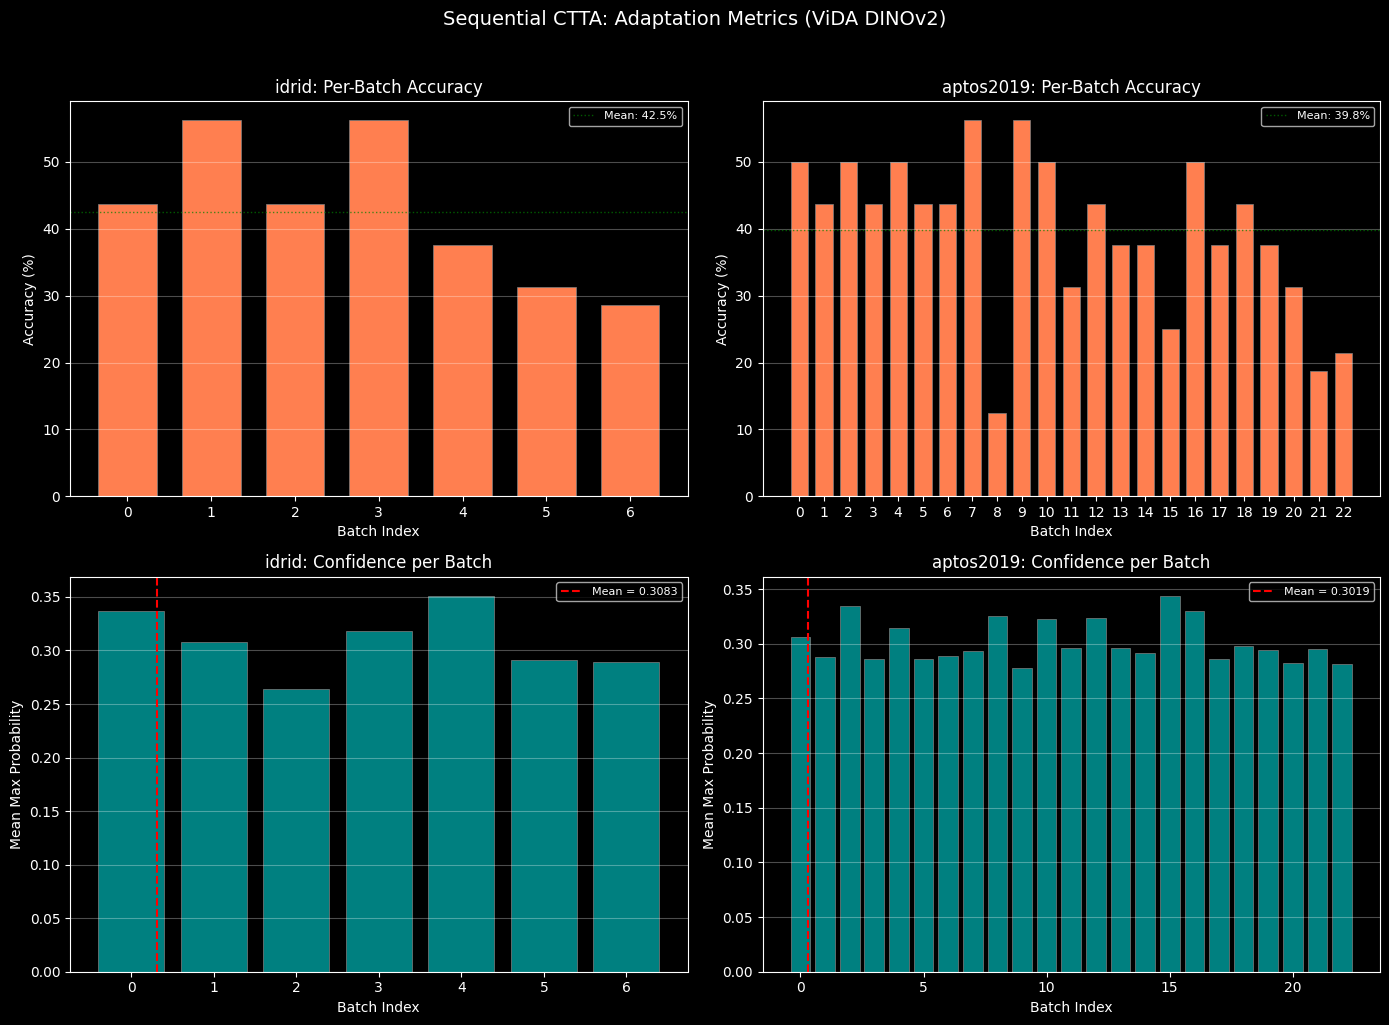

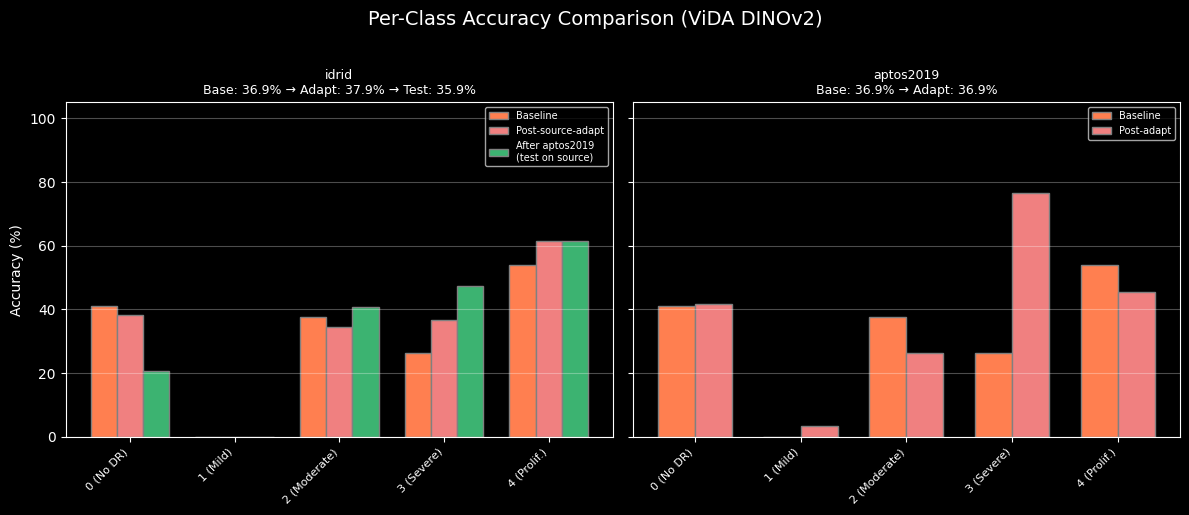

In [5]:
from pathlib import Path
from src.viz import (
    load_standalone_results,
    plot_sequential_qwk_comparison,
    plot_sequential_overall_accuracy,
    plot_sequential_forgetting,
    plot_sequential_adaptation_comparison,
    plot_sequential_per_class_accuracy,
    print_sequential_summary,
)

plots_dir = Path(config.output_dir) / 'plots'
plots_dir.mkdir(exist_ok=True)

print_sequential_summary(results, method_name='ViDA DINOv2')
plot_sequential_qwk_comparison(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_overall_accuracy(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_forgetting(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_adaptation_comparison(results, plots_dir, method_name='ViDA DINOv2')
plot_sequential_per_class_accuracy(results, plots_dir, method_name='ViDA DINOv2')